# Weak SINDy for ODEs

Previous tutorials established the fundamental issue of noise in numerical differentiations. Whilst it can be mitigated with data smoothing, what if we can simply avoid numerical differentiation? The weak form of SINDy presents a mean of bypassing numerical differentiation. The SINDy weak form has been proposed by several groups independently, such as [(Schaeffer and McCalla, 2017)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.96.023302), [(Reinbold et al, 2020)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.101.010203), and [(Messenger and Bortz, 2021)](https://epubs.siam.org/doi/abs/10.1137/20M1343166) for ODEs and [(Messenger and Bortz, 2021)](https://www.sciencedirect.com/science/article/pii/S0021999121004204) for PDEs. We base this tutorial off of [(Messenger and Bortz, 2021)](https://epubs.siam.org/doi/abs/10.1137/20M1343166) method where their code is available as [MATLAB code](https://github.com/MathBioCU/WSINDy_ODE). Our Python implementation of this method is found in `WSINDy_ODE`. In this tutorial, we will cover the fundamental building blocks of the weak form SINDy which are
1. Understanding the overall weak form formulation
2. Construction of test functions
3. Placement of test functions
4. Formulation as a sparse regression problem

In [1]:
# Import all required libraries

import numpy as np
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Math

from sindy.weak.wsindy_ode import \
    WSINDy_ODE, \
    benchmark_wsindy_ode, \
    wsindy_param_plot
from sindy.ivp_solvers import rk4
from sindy.utils import set_seed
from sindy.odes import generate_ode_data, duffing, van_der_pol, lorenz
from sindy.plot_utils import init_plt_format

warnings.filterwarnings('ignore', category=RuntimeWarning)
init_plt_format()
set_seed(0)

# Weak Form Formulation: A Galerkin Based Approach

Given a first-order ODE of the form
$$\frac{d}{dt}\mathbf{x}(t) = \mathbf{F}(\mathbf{x}(t))$$
$$\mathbf{x}(0)=\mathbf{x}_0 \in \mathbb{R}^D$$

We wish to identify the exact form of the equation from $M$ data points which may be noisy. The noise is assumed to be Gaussian and additive in nature such that
$$\mathbf{y} = \mathbf{x} + \epsilon$$

where $\epsilon \in \mathbb{R}^D$ is sampled from a zero mean Gaussian distribution with $\sigma^2$ variance.

In order to bypass the need to numerically differentiating the data $\mathbf{x}$, let us multiply a smooth test function $\phi: \mathbb{R} \rightarrow \mathbb{R}$ that is also compact on the domain $[a,b]$ on both sides of the ODE such that

$$\phi \frac{d\mathbf{x}}{dt} = \phi \mathbf{F}(\mathbf{x}(t))$$
$$\int_a^b \phi(t) \frac{d\mathbf{x}}{dt} \,dt = \int_a^b \phi(t) \mathbf{F}(\mathbf{x}(t)) \,dt.$$

> In general, compactness is a property that refers to a set or domain being closed and bounded. For functions $\phi(x)$ that exist in the domain of $x \in \mathbb{R}$ (one-dimensional space), it is said to be compactly supported if the values of $\phi(x)$ are zero everywhere outside of the domain $[a,b]$. Since $\phi$ is also a smooth function, this means that it must also converge to zero at its boundaries such that $\phi(a) = \phi(b) = 0$.

The left hand side of this equation can be rewritten using integration by parts
$$\int_a^b \phi(t) \frac{d\mathbf{x}}{dt} \,dt = \cancel{\phi(b)}\mathbf{x}(b) - \cancel{\phi(a)}\mathbf{x}(b) - \int_a^b \phi'(t) \mathbf{x}(t) \,dt,$$

and since the function $\phi(x)$ is zero at the boundaries, this reduces the integral equation to 
$$- \int_a^b \phi'(t) \mathbf{x}(t) \,dt = \int_a^b \phi(t) \mathbf{F}(\mathbf{x}(t)) \,dt$$

following the compactness assumption of $\phi$. And by restructuring $\mathbf{F}(\mathbf{x}(t))$ as a linear combination of nonlinear functions, we obtain
$$- \int_a^b \phi'(t) \mathbf{x}(t) \,dt = \int_a^b \phi(t) \left( \sum_{j=1}^J w_j f_j(\mathbf{x}(t)) \right) \,dt$$

By using trapezoidal numerical integration and repeating the process using $K$ test functions, we may construct integration matrices $\mathbf{V} \in \mathbb{R}^{K \times M}$ and $\mathbf{V'} \in \mathbb{R}^{K \times M}$ such that
$$
\begin{aligned}
    \mathbf{V}_{km} &= \Delta t \phi_k(t_m) \\
    \mathbf{V'}_{km} &= \Delta t \phi'_k(t_m).
\end{aligned}
$$

> The way we select our $K$ number of test functions has a major impact on the performance of the method. The choices mainly surrounds where we position and distribute the functions on the domain, how many functions in total, and the size of the compact domain that supports each function.

Note that the magnitude of the $\Delta t/2$ trapezoidal integration quadrature points at the boundaries are irrelevant due to the compactness assumption of $\phi$ and can be assumed to be $\Delta t$ for simplicity. These integration matrices are then used to construct our sparse regression problem of
$$-\mathbf{V'} \mathbf{x} = \mathbf{V} \mathbf{\Theta(\mathbf{x})}\mathbf{w}$$

where $\Theta(\mathbf{x}) \in \mathbb{R}^{M \times J}$ is the library of candidate functions. From here, it is possible to solve for $\mathbf{w} \in \mathbb{R}^{J \times D}$ using a sparse regression formula such as STLSQ such that

$$
\mathbf{w} = \underset{w}{\arg\!\min} \left\{
    (\mathbf{G} \mathbf{w} - \mathbf{b})^T (\mathbf{G} \mathbf{w} - \mathbf{b}) + \gamma^2 ||w||^2_2
\right\}
$$

where $\mathbf{G} = \mathbf{V} \mathbf{\Theta(\mathbf{x})}$ and $\mathbf{b} = -\mathbf{V'} \mathbf{x}$.

## The Test Function

Messenger proposes the use of unimodal piecewise polynomials in the form

$$
\phi(t) =
\begin{cases}
C(t-a)^p(b-t)^p & t \in [a,b], \\
0 & \text{otherwise}
\end{cases}
$$

where its normalization factor

$$C = \left( \frac{2}{b-a} \right) ^ {2p}$$

to ensure $\max \phi = 1$. The degree of the polynomial controls the 'radius' of the test function. For instance,

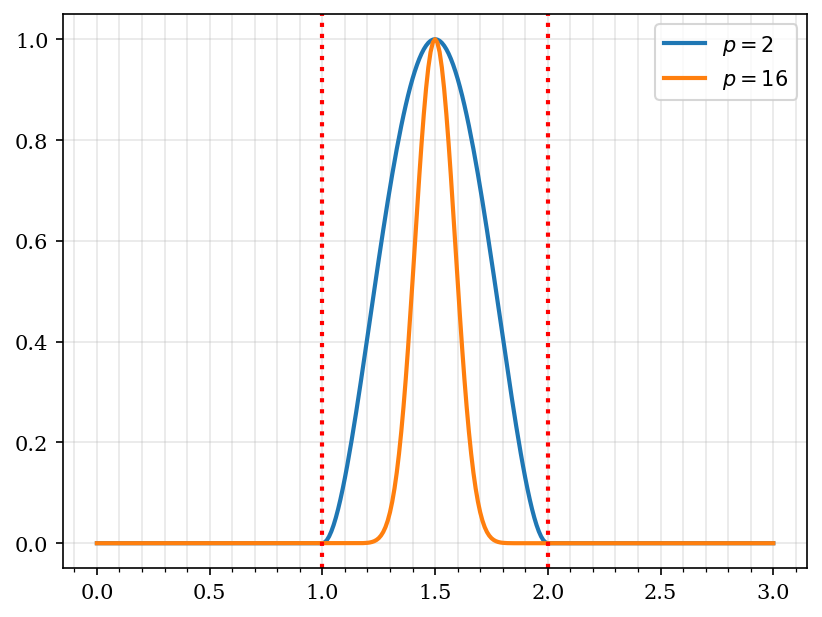

In [2]:
# Define t
t: np.ndarray = np.linspace(0,3,301)

# Define polynomial order
p1: int = 2
p2: int = 16

# Define test function domain
a: float = 1.
b: float = 2.

# Create wsindy object
wsindy = WSINDy_ODE()

phi1 = wsindy._unimodal_poly(t, a, b, p1, p1)[0]
phi2 = wsindy._unimodal_poly(t, a, b, p2, p2)[0]

# Visualize the test functions
plt.plot(t, phi1, label=f'$p = {p1}$')
plt.plot(t, phi2, label=f'$p = {p2}$')
plt.axvline(a, color='r', ls=':')
plt.axvline(b, color='r', ls=':')
plt.legend();

## Placements of the Test Function

There are a number of methods to position test functions among the domain. For instance, PySINDy's `WeakPDELibrary` implements random domain placement based on a specified number of test functions. Messenger proposes two methods: uniform grid and adaptive grid. We refer to [(Messenger and Bortz, 2021)](https://epubs.siam.org/doi/abs/10.1137/20M1343166) for detailed justifications of the methods.

### Uniform Grid
The uniform grid parameterize the test function generation using a tuple of $(L, p, s)$ where
* $L$ is the number of discrete time points supporting each test function domain.
* $p$ is the polynomial order of the test function.
* $s$ is the value of $\phi$ at the intersection of neighboring test functions.

The paper suggests choosing $L = \lfloor M/25 \rfloor$. The optimal selection of $L$ can be reasoned from the active wavemode of the given data as described in [Weak SINDy for PDEs](https://www.sciencedirect.com/science/article/pii/S0021999121004204) paper. The $p$ and $s$ are hyperparameters that must be selected as described in the paper, and later sections of this notebook will demonstrate its effects on the resulting model. From these parameters, $\mathbf{V}_{km} = \Delta t \phi_k(t_m), \mathbf{V'}_{km} = \Delta t \phi'_k(t_m)$ can be obtained.

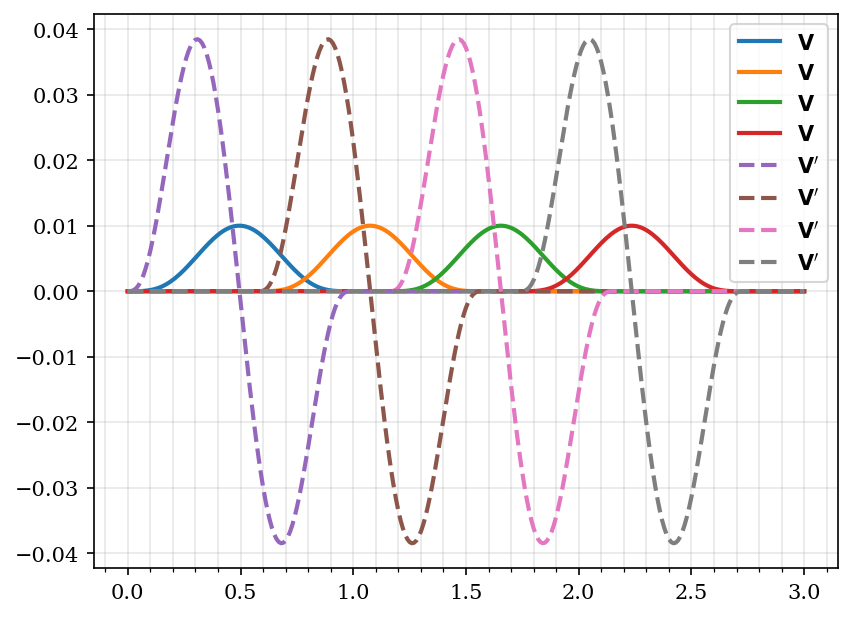

In [3]:
# Obtain integration matrices
V, Vp = wsindy._uniform_grid(
    t, L=100, s=0.2, p=4
)

plt.plot(t, V.T, label=r'$\mathbf{V}$');
plt.plot(t, Vp.T, '--', label=r"$\mathbf{V}'$");
plt.legend();

### Adaptive Grid
From residual analysis of the error terms, Messenger argued that centering $\phi_k$ around large changes or variations in $\mathbf{x}$ would lead to cancellation of certain residual components. In order to locate large variations of $\mathbf{x}$, we differentiate $\mathbf{x}$ using weak form derivative where
$$\dot{\mathbf{x}} \approx \mathbf{v}_m = -\left< \phi', \mathbf{x} \right>$$

Let us first create a test dataset with a mix of low frequency, high amplitude signal with a high frequency, low amplitude noise-like signal.

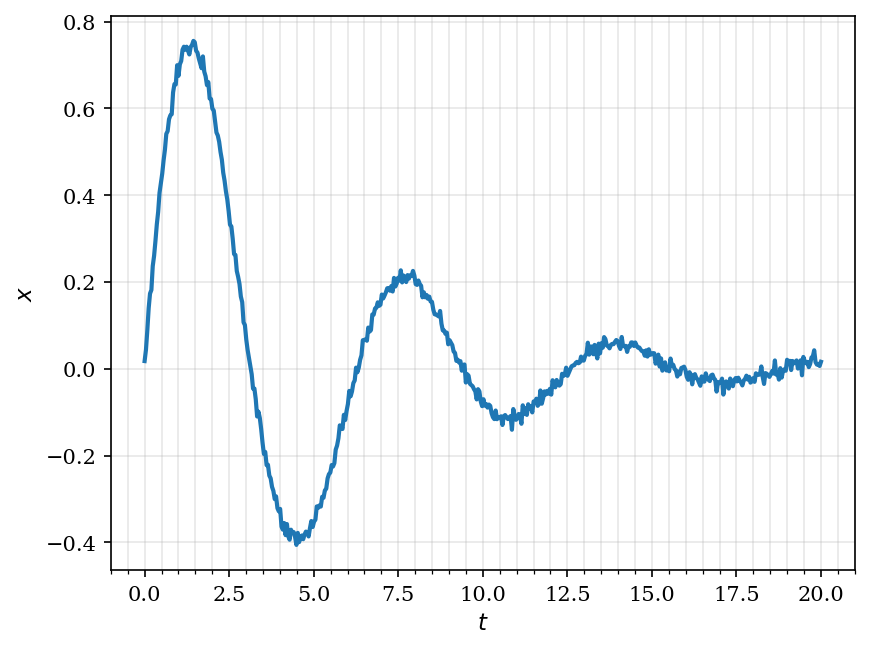

In [4]:
t = np.linspace(0, 20, 500)
x = np.exp(-0.2*t) * np.sin(t) + np.random.normal(0, 0.01, size=t.shape)

plt.plot(t, x)
plt.xlabel('$t$')
plt.ylabel('$x$');

Let us apply the weak derivative on this test data.

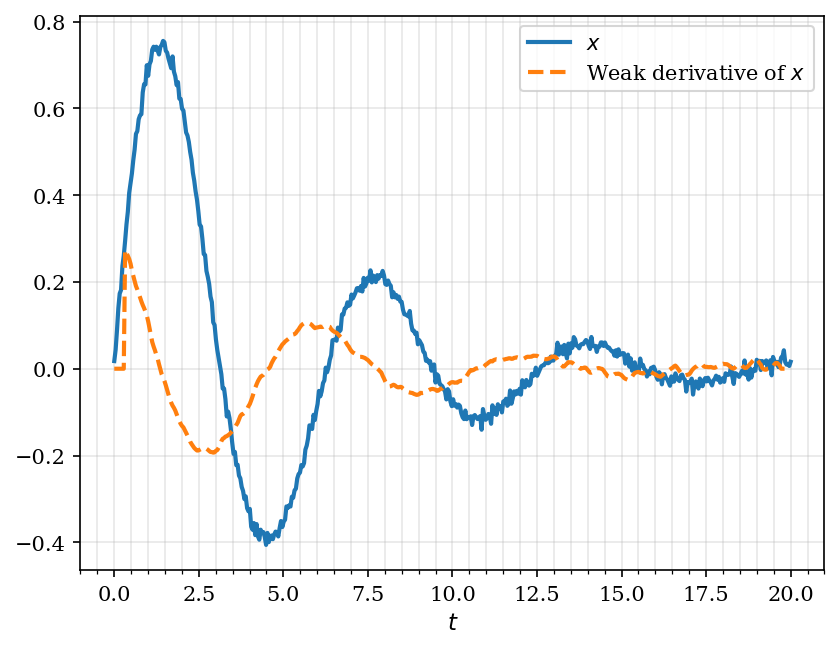

In [5]:
weak_derivative = wsindy._weak_deriv_approx(t, x)

plt.plot(t, x, label='$x$')
plt.plot(t, weak_derivative, '--', label='Weak derivative of $x$')
plt.xlabel('$t$')
plt.legend();

The weak derivative informs us where the data changes most rapidly which would inform us the most about its dynamics, without actually differentiating the data. Hence, if we now formulate the center points using this information, we will only sample from the most informative regions of the data. 

Then, let us define the cumulative sum of $|\mathbf{v}_m|$ as $\psi$ which has a distribution density proportional to the total variation of $\mathbf{x}$. If we sample uniformly from the inverse of $\psi$, we can aggregate the positioning of test functions at regions of high variations.

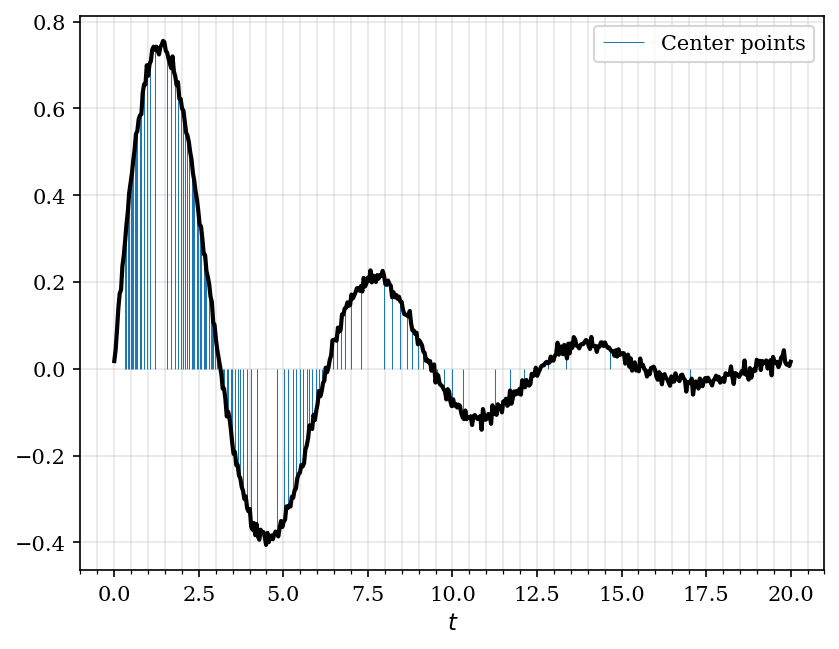

In [6]:
centers = wsindy._get_centres(weak_derivative, K=100)

plt.vlines(
    t[centers], np.zeros((len(centers),)), x[centers],
    linewidth=0.5, label='Center points'
)
plt.plot(t, x, 'k')
plt.xlabel('$t$')
plt.legend();

Finally, to generate the test functions given the center points, let us parameterize the support points of the test functions as $r_{whm}$ which defines the width at half max, such that if $\phi_k$ is centered around $c_k$, then

$$\phi_k(c_k \pm r_{whm}) = \frac{1}{2}$$

We also define a second constraint where

$$\phi_k(b_k - \Delta t) = 10^{-16}$$

The total number of support points for the test function and the polynomial degree $p$ used can be determined by solving these two constraints. These are solved in `WSINDy_ODE._get_test_func_param` using Brent's root solver. The default $r_{whm}$ as suggested by the paper should be $\lfloor M/100 \rfloor$. It is important to note whilst the proposed adaptive grid method provides the center points and supporting widths of the test functions, one must still ensure compactness assumption of the test function near the boundaries of the time domain.

An example of such adaptive grid would be

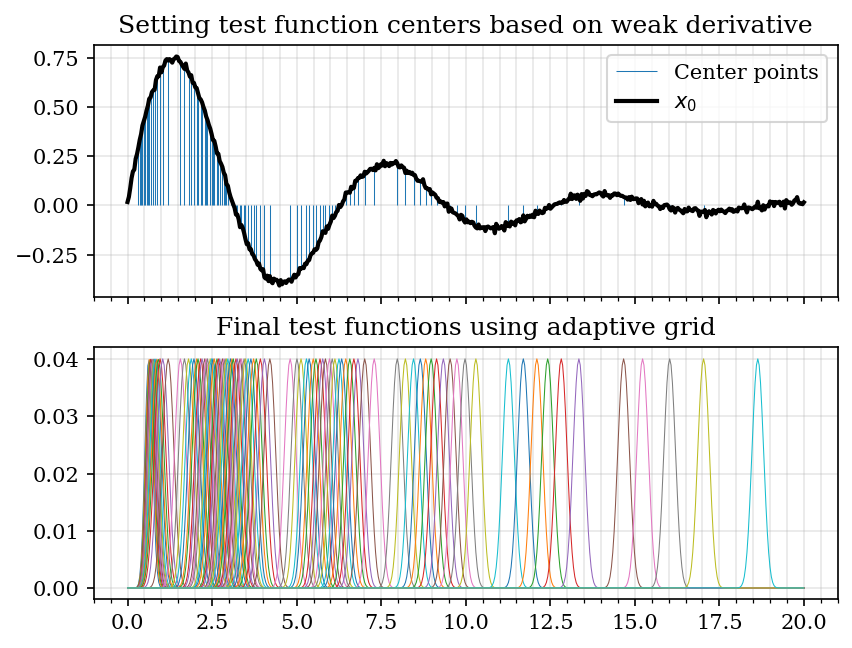

In [7]:
# Get test function center points
centers = wsindy._get_centres(weak_derivative, K=100)

# Compute matrix V
V = wsindy._adaptive_grid(
    t, x,
    100, int(np.floor(len(t)/100))
)[0]

_, axs = plt.subplots(2, 1, sharex=True)

axs[0].vlines(
    t[centers], np.zeros((len(centers),)), x[centers],
    linewidth=0.5, label='Center points'
)
axs[0].plot(t, x, 'k', label='$x_0$')
axs[0].legend()
axs[0].set_title('Setting test function centers based on weak derivative')

axs[1].plot(t, V.T, linewidth=0.5)
axs[1].set_title('Final test functions using adaptive grid');

As shown above, the test functions are centered around regions of the highest change in the original timeseries data.

# Solving the Sparse Regression Problem

Once we have obtained $\mathbf{V}$ and $\mathbf{V'}$ via either uniform or adaptive grid method, we can construct an ordinary least squares sparse regression

$$
\mathbf{w} = \underset{w}{\arg\!\min} \left\{
    (\mathbf{G} \mathbf{w} - \mathbf{b})^T(\mathbf{G} \mathbf{w} - \mathbf{b}) + \gamma^2 ||w||^2_2
\right\}
$$

to be sequentially thresholded. The ridge regression strength is defined by $\gamma$.

> Note that a generalised least squares regression can also be constructed to address error residuals such that
$
\mathbf{w} = \underset{w}{\arg\!\min} \left\{
    (\mathbf{G} \mathbf{w} - \mathbf{b})^T \Sigma^{-1} (\mathbf{G} \mathbf{w} - \mathbf{b}) + \gamma^2 ||w||^2_2
\right\}
$ where the covariance matrix is defined as $\Sigma = V'(V')^T$.

The aforementioned steps are assembled in `WSINDy_ODE.fit` function as shown here:

In [8]:
WSINDy_ODE.fit??

Signature: WSINDy_ODE.fit(self, x: numpy.ndarray, t: numpy.ndarray) -> numpy.ndarray
Source:   
    def fit(self, x: np.ndarray, t: np.ndarray) -> np.ndarray:
        """
        Function to discover the sparse coefficient matrix.

        Args:
            x (np.ndarray): Data matrix x.
            t (np.ndarray): Time vector t. Assumes uniform time sampling.

        Returns:
            np.ndarray: The discovered coefficient matrix.
        """

        # Get total number of data points
        self.M: int = x.shape[0]

        # Get total number of states
        self.N: int = x.shape[1]
        
        # Set default span of test functions if none provided
        if self.L is None:
            self.L = int(np.floor(self.M/25))

        # Set default half height width in points if none provided
        if self.r_whm is None:
            self.r_whm = int(np.floor(self.M/100))

        # Obtain candidate function library
        self.theta, self.lib_names = poly_lib(x, self.poly_ord

# Data Generation

Now that we have a complete method, let us generate data for Duffing oscillator, Van der Pol equation and the Lorenz chaotic system to apply weak form SINDy on. See the [data generation](../../S0%20Miscellaneous/Data%20Generation.ipynb) tutorial for more information on these equations.

In [9]:
# Define noise ratios to test
noise_ratios: np.ndarray = np.logspace(-6, 0)

# ------------------------ Duffing ODE ------------------------ #

# Define the parameters of the Duffing ODE
duffing_params: list = [0.2, 0.05, 1]

# Generate Duffing ODE
duffing_t, duffing_x, duffing_noisy_xs = generate_ode_data(
    M=3001, dt=0.01,
    x0=np.array([0,2]),
    ode=duffing, ode_params=duffing_params, ivp_solver=rk4,
    noise_ratios=noise_ratios
)

# ------------------------ Van Der Pol ------------------------ #

# Define the parameters of the Duffing ODE
vdp_params: list = [4]

# Generate Duffing ODE
vdp_t, vdp_x, vdp_noisy_xs = generate_ode_data(
    M=3001, dt=0.01,
    x0=np.array([0,1]),
    ode=van_der_pol, ode_params=vdp_params, ivp_solver=rk4,
    noise_ratios=noise_ratios
)

# ------------------------ Lorenz ------------------------ #

# Define the parameters of the Lorenz ODE
lorenz_params: list = [10, 8/3, 28]

# Generate Lorenz system
lorenz_t, lorenz_x, lorenz_noisy_xs = generate_ode_data(
    M=1001, dt=1e-2,
    x0=10*np.ones(3),
    ode=lorenz, ode_params=lorenz_params, ivp_solver=rk4,
    noise_ratios=noise_ratios
)

# Demonstration of WSINDy

Let us attempt to recover the equations using clean data first.

## Duffing Oscillator

In [10]:
wsindy = WSINDy_ODE(poly_order=3, include_bias=True, lam=1e-2)
wsindy.fit(duffing_x, duffing_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

## Van der Pol Oscillator

In [11]:
wsindy.fit(vdp_x, vdp_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

## Lorenz System

In [12]:
wsindy.fit(lorenz_x, lorenz_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

# Benchmarking Weak Form SINDy

To demonstrate why weak form is the preferred method when handling noisy data, let us generate a series of test data with additive Gaussian noise as explained in [data generation notebook](../../S0%20Miscellaneous/Data%20Generation.ipynb). Then evaluate them using relative Frobenius norm error and precision as defined in [error metrics notebook](../../S0%20Miscellaneous/Error%20Metrics.ipynb).

Let us define the parameters for WSINDy here:

In [13]:
# Define SINDy algorithm parameter
lam: float = 1e-2

# Define polynomial library parameters (changing these would require changing
# the true coefficient matrices of all the ODEs)
poly_order: int = 5
include_bias: bool = True

Let us define the true coefficient matrix for each ODE to compare our results against.

In [14]:
# True sparse weight matrices with 5th order polynomial library with bias term
# for Duffing ODE
duffing_true_xi = np.zeros((21, 2))
duffing_true_xi[2, 0] = 1.0
duffing_true_xi[1, 1] = -duffing_params[1]
duffing_true_xi[2, 1] = -duffing_params[0]
duffing_true_xi[6, 1] = -duffing_params[2]

# True sparse weight matrices with 5th order polynomial library with bias term
# for Van der Pol ODE
vdp_true_xi = np.zeros((21, 2))
vdp_true_xi[2, 0] = 1.0
vdp_true_xi[1, 1] = -1.0
vdp_true_xi[2, 1] = vdp_params[0]
vdp_true_xi[7, 1] = -vdp_params[0]

# True sparse weight matrices with 5th order polynomial library with bias term
# for Lorenz ODE
lorenz_true_xi: np.ndarray = np.zeros((56,3))
lorenz_true_xi[1,0] = -lorenz_params[0]
lorenz_true_xi[2,0] = lorenz_params[0]
lorenz_true_xi[1,1] = lorenz_params[2]
lorenz_true_xi[2,1] = -1.0
lorenz_true_xi[6,1] = -1.0
lorenz_true_xi[3,2] = -lorenz_params[1]
lorenz_true_xi[5,2] = 1.

## Duffing Oscillator

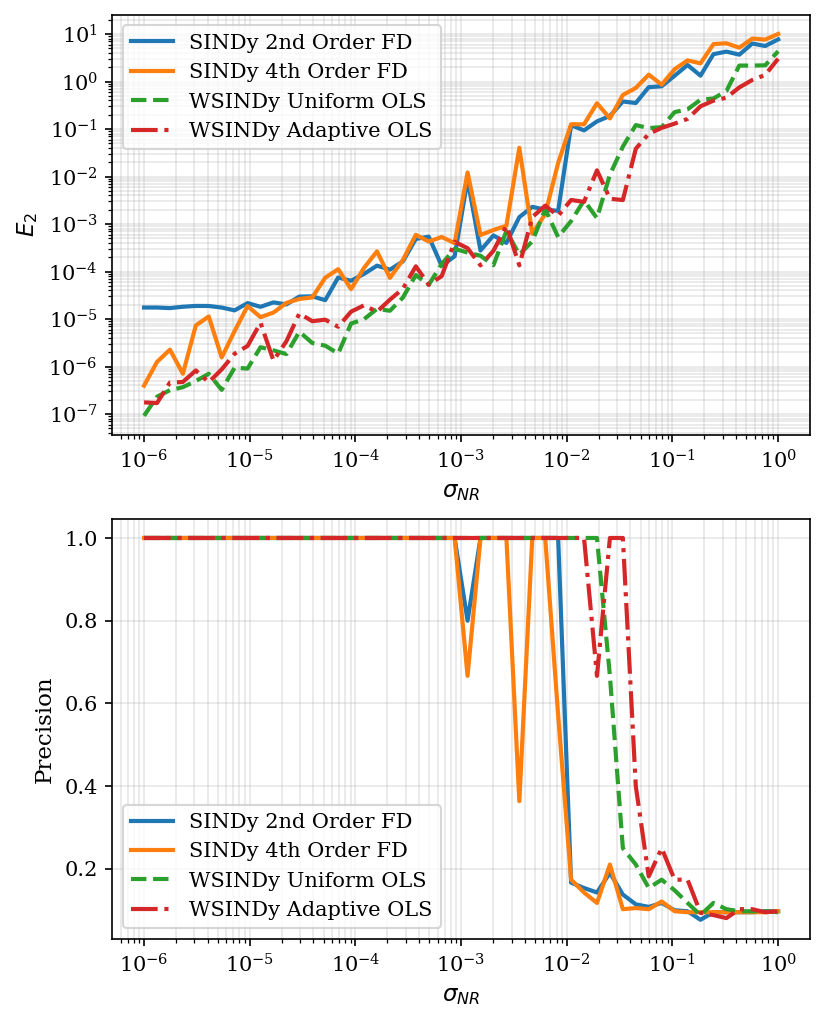

In [15]:
benchmark_wsindy_ode(
    duffing_noisy_xs, duffing_t, noise_ratios,
    poly_order, include_bias, lam,
    duffing_true_xi
)

## Van der Pol Oscillator

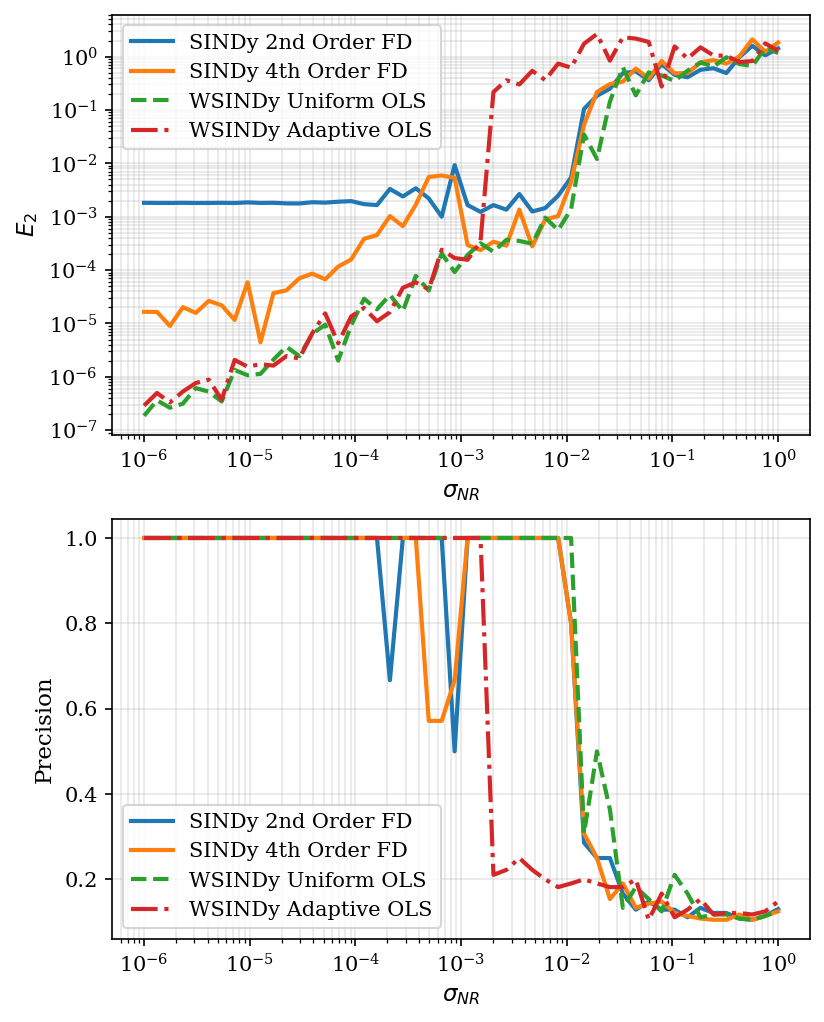

In [16]:
benchmark_wsindy_ode(
    vdp_noisy_xs, vdp_t, noise_ratios,
    poly_order, include_bias, lam,
    vdp_true_xi
)

## Lorenz System

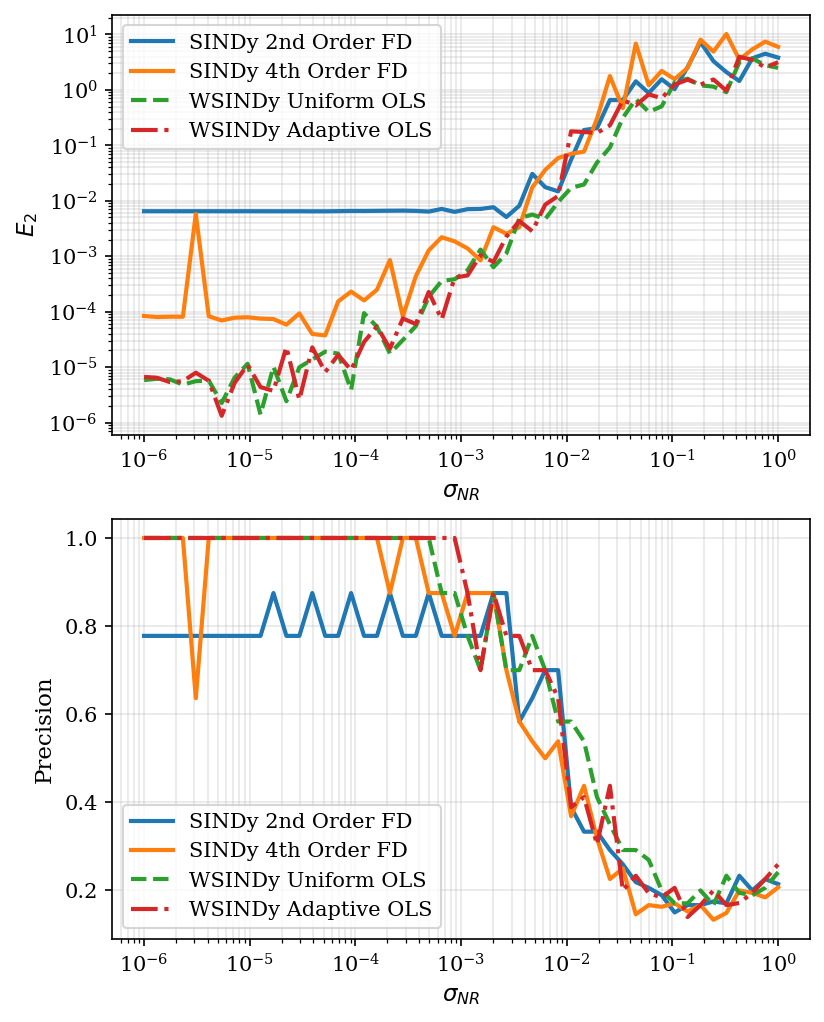

In [17]:
benchmark_wsindy_ode(
    lorenz_noisy_xs, lorenz_t, noise_ratios,
    poly_order, include_bias, lam,
    lorenz_true_xi
)

Note that in general, the performance of weak form SINDy is superior to using finite difference in the high noise regime. Additionally, its accuracy is also higher in the low noise regime as well, since finite difference introduces numerical truncation errors. This reduces the sensitivity of weak form SINDy to the choice of the threshold hyperparameter $\lambda$ and allows for the recovery of sparse models even with very low values of $\lambda$.

# Hyperparameter Selection

As detailed in the paper, this section will demonstrate the effect of choices of $p$ and $s$ hyperparameters on the error of the discovered equations. Note that $p$ has been re-parameterized as $\rho := ||\phi_k'||_2 / ||\phi_k||_2$ such that

$$ p = \left\lfloor \frac{1}{8} \left( ((b-a)^2 \rho^2 - 1) + \sqrt{((b-a)^2 \rho^2 - 1)^2 - 8(b-a)^2 \rho^2} \right) \right\rfloor $$

In [18]:
# Define intervals of s and rho to plot
s_vars: np.ndarray = np.linspace(0.3, 0.95, 10)
rho_vars: np.ndarray = np.linspace(1, 7, 20)

## Duffing Oscillator

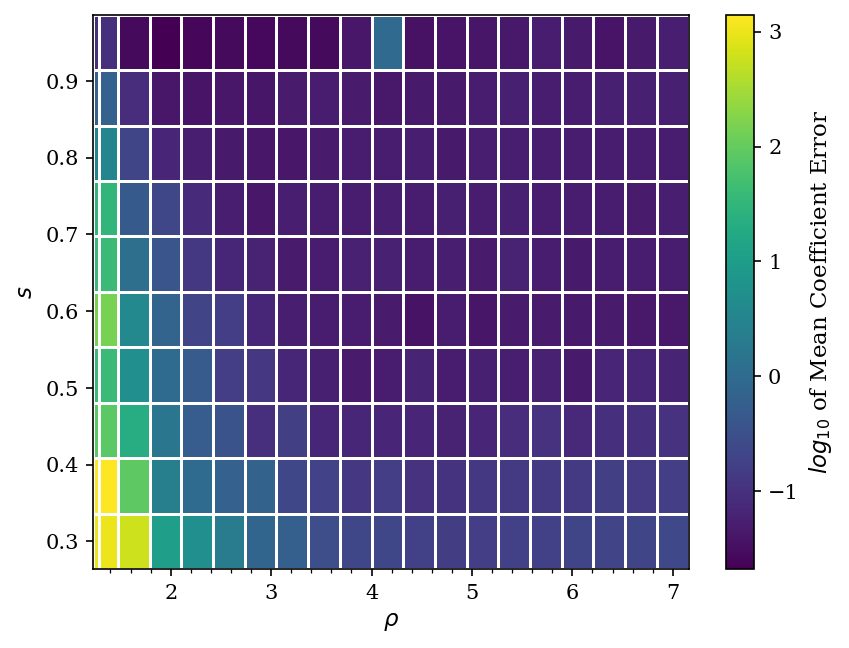

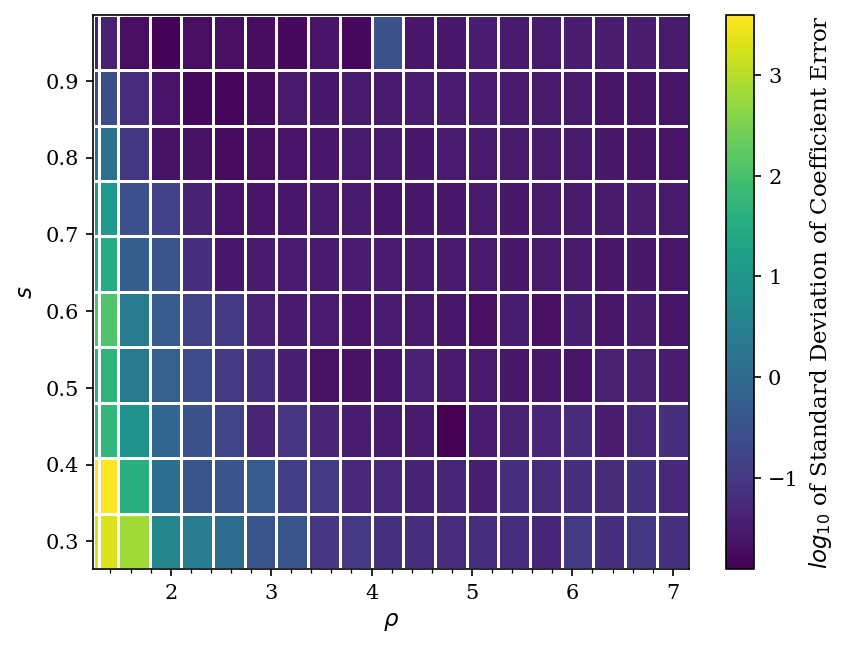

In [19]:
duffing_t, duffing_x, duffing_noisy_xs = generate_ode_data(
    M=3001, dt=0.01,
    x0=np.array([0,2]),
    ode=duffing, ode_params=duffing_params, ivp_solver=rk4,
    noise_ratios=0.04 * np.ones((10,))
)

wsindy_param_plot(
    xs=duffing_noisy_xs, t=duffing_t,
    s_vars=s_vars, rho_vars=rho_vars,
    lam=lam, poly_order=poly_order, include_bias=include_bias,
    L=250,
    true_w=duffing_true_xi
)

## Van der Pol Oscillator

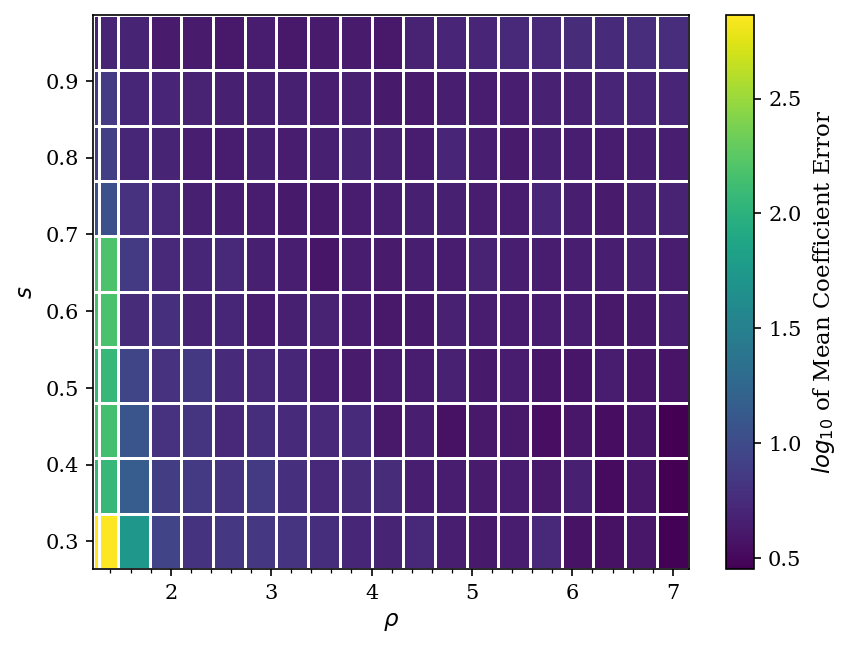

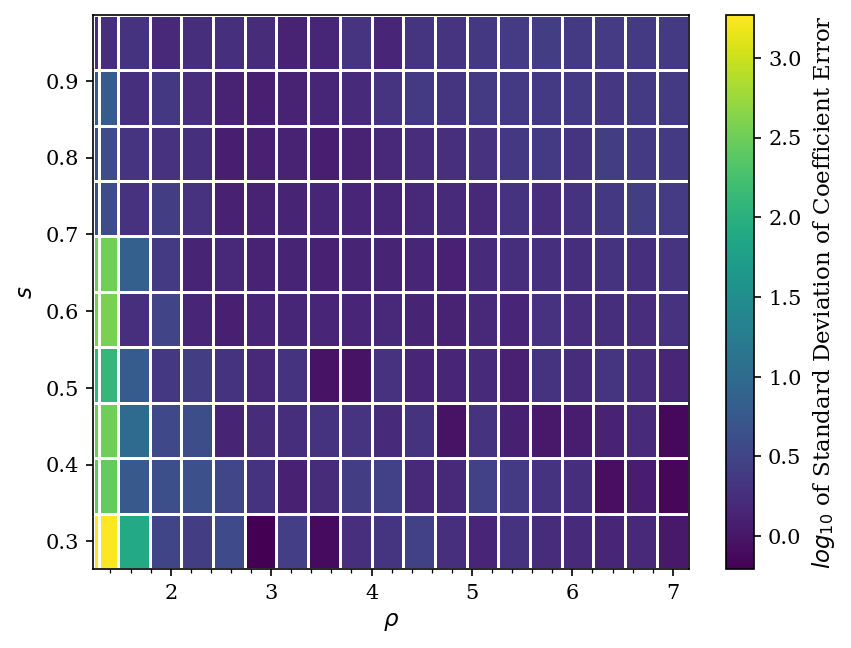

In [20]:
vdp_t, vdp_x, vdp_noisy_xs = generate_ode_data(
    M=3001, dt=0.01,
    x0=np.array([0,1]),
    ode=van_der_pol, ode_params=vdp_params, ivp_solver=rk4,
    noise_ratios=0.04 * np.ones((10,))
)

wsindy_param_plot(
    xs=vdp_noisy_xs, t=vdp_t,
    s_vars=s_vars, rho_vars=rho_vars,
    lam=lam, poly_order=poly_order, include_bias=include_bias,
    L=250,
    true_w=duffing_true_xi
)

Generally speaking, the higher the overlap between test functions (as governed by $s$) and the higher the polynomial degree, the better the method will perform. However, higher polynomial orders require more test functions to achieve the same degree of overlap and consequently, requires more data points in the weak basis. Whilst a balance should be achieved between accuracy and the total computation required, SINDy itself is a fast-running lightweight algorithm. Therefore, it is generally safer to choose more test functions for better performance.